# Cox Proportional Hazard Modeling
Beginning from the most simple clinical metadata, we will test Cox Proportional Hazards Modeling to predict cancer survival

In [236]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
import pyhere as here

In [237]:
here.here()

PosixPath('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction')

In [238]:
# load clinical metadata with PCA + UMAP features
pca_clinical_df = pd.read_csv(here.here("data", "processed","clinical_dimred_features.csv"))

In [239]:
pca_clinical_df

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,...,PC283_harmony,PC284_harmony,PC285_harmony,PC286_harmony,PC287_harmony,PC288_harmony,PC289_harmony,PC290_harmony,PC291_harmony,PC292_harmony,PC293_harmony,PC294_harmony,PC295_harmony,PC296_harmony,PC297_harmony,PC298_harmony,PC299_harmony,PC300_harmony,UMAP1,UMAP2
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,...,0.336686,-0.097124,-0.429184,0.248860,0.378603,-0.036357,-0.343882,-0.029212,-0.247317,0.992405,0.244572,-0.496506,0.168578,0.533063,0.434756,0.272053,0.324875,-0.103091,-1.800003,-6.149750
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,...,-0.373885,-0.840345,-0.125027,-0.764974,1.066730,-0.372239,-0.551250,0.829832,-0.763762,-0.087889,0.303471,-0.844191,-0.596785,0.820834,0.064187,-0.056478,0.407295,0.292778,-2.570254,-2.240858
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,...,-1.076510,0.068082,-0.205204,-0.954994,0.230225,0.497247,0.378535,-0.314027,0.040458,-0.111406,0.059991,-0.518747,0.594953,0.316483,0.071531,0.090688,0.333440,0.199574,-5.767281,-4.865173
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,...,-1.011477,-0.456412,-0.285193,-0.346371,0.059027,-0.820278,0.247326,-0.716374,0.618912,1.394936,-0.689182,0.091264,-0.301379,-0.521918,0.213592,-0.737401,1.100436,-0.762680,-5.721486,-4.890594
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,...,0.851206,-0.328724,-0.807275,-0.018960,0.470403,-1.161407,0.768673,-0.027492,-0.148645,0.066970,-0.590699,-0.293891,1.523677,-1.229448,0.036228,0.395598,0.133042,0.194311,-1.569188,-1.622840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Lobular,1,Pre,3,Right,1.0,...,-0.421118,0.078009,0.076561,0.216721,-0.050059,0.983373,0.125546,-0.884114,-0.745798,0.048761,-0.457317,0.608927,0.001513,-0.051347,0.044357,-0.138593,-0.374052,0.445042,-1.645502,-3.813061
1900,7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,GAIN,Positive,Ductal/NST,0,Pre,5,NaN,1.0,...,-0.209247,0.032413,-0.695790,0.635284,1.142584,0.190176,-0.270994,-0.157265,-0.415426,-0.111104,0.176880,0.559336,0.212478,0.075198,-0.336113,-0.213558,0.347952,0.099582,-1.342959,-1.388248
1901,7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,Left,45.0,...,-0.193349,-0.576595,0.364917,0.366342,-0.195084,-0.538517,-0.134982,-0.504171,-0.107480,0.410147,-0.460358,0.201798,-0.437061,0.109682,-0.401253,-0.174120,-0.289600,0.339712,-3.293207,-0.444603
1902,7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,NaN,12.0,...,-0.292980,0.431660,-0.155014,-0.103469,-0.464207,-0.323776,-0.422704,0.054260,-0.494590,-0.216204,0.399676,-0.208885,0.881920,0.048649,0.519081,-0.593877,-0.908927,0.127365,-3.40658

In [240]:
pca_clinical_df["inferred_menopausal_state"].value_counts()

inferred_menopausal_state
Post    1493
Pre      411
Name: count, dtype: int64

### Preprocess data for cox model functions (Drop missing values and One-hot encoding)

In [241]:
def preprocess_for_cox(df, duration_col, event_col):
    # Drop rows with missing values in duration or event columns
    df = df.dropna(subset=[duration_col, event_col])
    
    # Ensure duration column is numeric
    df[duration_col] = pd.to_numeric(df[duration_col], errors='coerce')
    
    # Drop rows with non-numeric duration values
    df = df.dropna(subset=[duration_col])
    
    return df

In [242]:
# converts float columns with whole numbers to integer type
def convert_whole_float_columns_to_int(df):
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            # Check if all non-null values are whole numbers
            if df[col].dropna().apply(float.is_integer).all():
                df[col] = df[col].astype("Int64")  # nullable integer type
    return df

In [243]:
def one_hot_encode(df, convert_whole_num_ints=True):
    # One hot encode categorical variables

    # Identify categorical columns automatically
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Apply one-hot encoding only to categorical columns
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Change boolean columns to integers
    bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
    
    if convert_whole_num_ints:
        df_encoded = convert_whole_float_columns_to_int(df_encoded)
    return df_encoded

In [244]:
# One hot encode categorical variables

df_encoded = one_hot_encode(pca_clinical_df)

In [245]:
df_encoded.dtypes.value_counts()

float64    306
int64       62
Int64        4
Name: count, dtype: int64

In [246]:
df_encoded = convert_whole_float_columns_to_int(df_encoded)

In [247]:
df_encoded.dtypes

patient_id                                  int64
age_at_diagnosis                          float64
chemotherapy                                int64
cohort                                      Int64
neoplasm_histologic_grade                   Int64
                                           ...   
tumor_stage_3.0                             int64
tumor_stage_4.0                             int64
tumor_stage_unknown                         int64
death_from_cancer_Died of Other Causes      int64
death_from_cancer_Living                    int64
Length: 372, dtype: object

In [248]:
# save one-hot encoded clinical metadata with PCA + UMAP features
df_encoded.to_csv(here.here("data", "processed","clinical_dimred_features_onehot.csv"), index=False)

## Cox Proportional Hazards Model - Limited Clinical Data
#### We will start with only a few strong clinical features, and expand from there

In [249]:
# start with strongest clinical features only
baseline_cols = [
    "overall_survival_months",   # time
    "death_from_cancer",         # event
    "age_at_diagnosis",          
    "tumor_size",
    "tumor_stage",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status"
]


In [250]:
# subset for cox model 
df_cox = pca_clinical_df[baseline_cols]

# preprocess for cox model
df_cox = preprocess_for_cox(df_cox, duration_col="overall_survival_months", event_col="death_from_cancer")
df_cox = one_hot_encode(df_cox)

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_21226/1554145649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[duration_col] = pd.to_numeric(df[duration_col], errors='coerce')


In [251]:
# UPDDATE: Neoplasm histologic grade data is reversed, so we will flip it to match expected ordering (grade 1 = well differentiated, grade 3 = poorly differentiated)
df_cox["neoplasm_histologic_grade"] = (
    df_cox["neoplasm_histologic_grade"]
    .map({1: 3, 2: 2, 3: 1})
)

In [252]:
pca_clinical_df["death_from_cancer"].value_counts()

death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
Name: count, dtype: int64

In [253]:
# death from cancer value counts after one-hot encoding
# we also have "Died from Other Causes", which we will treat as censored
df_cox[[ "death_from_cancer_Died of Other Causes","death_from_cancer_Living"]].value_counts()

death_from_cancer_Died of Other Causes  death_from_cancer_Living
0                                       1                           801
                                        0                           622
1                                       0                           480
Name: count, dtype: int64

In [254]:
df_cox

,overall_survival_months,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,death_from_cancer_Died of Other Causes,death_from_cancer_Living,tumor_stage_1.0,tumor_stage_2.0,tumor_stage_3.0,tumor_stage_4.0,tumor_stage_unknown,er_status_Positive,pr_status_Positive,her2_status_Positive
0,140.500000,75.65,22.0,10,1.0,0,1,0,1,0,0,0,1,0,0
1,84.633333,43.19,10.0,0,1.0,0,1,1,0,0,0,0,1,1,0
2,163.700000,48.87,15.0,1,2.0,0,0,0,1,0,0,0,1,1,0
3,164.933333,47.68,25.0,3,2.0,0,1,0,1,0,0,0,1,1,0
4,41.366667,76.97,40.0,8,1.0,0,0,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,43.10,25.0,1,1.0,0,1,0,0,0,0,1,1,1,0
1900,44.733333,42.88,20.0,1,1.0,0,0,0,0,0,0,1,1,0,1
1901,175.966667,62.90,25.0,45,1.0,0,0,0,0,0,0,1,1,1,0
1902,86.233333,61.16,25.0,12,2.0,1,0,0,0,0,0,1,1,1,0


In [255]:
# Rename for clarity
df_cox = df_cox.rename(columns={
    "overall_survival_months": "time",
    "death_from_cancer_Living": "event"
})
# Drop the "Died of Other Causes" column as we are treating it as censored
df_cox = df_cox.drop(columns=["death_from_cancer_Died of Other Causes"])
# Drop missing values (simple first version)
df_cox = df_cox.dropna()


In [256]:
df_cox

,time,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,event,tumor_stage_1.0,tumor_stage_2.0,tumor_stage_3.0,tumor_stage_4.0,tumor_stage_unknown,er_status_Positive,pr_status_Positive,her2_status_Positive
0,140.500000,75.65,22.0,10,1.0,1,0,1,0,0,0,1,0,0
1,84.633333,43.19,10.0,0,1.0,1,1,0,0,0,0,1,1,0
2,163.700000,48.87,15.0,1,2.0,0,0,1,0,0,0,1,1,0
3,164.933333,47.68,25.0,3,2.0,1,0,1,0,0,0,1,1,0
4,41.366667,76.97,40.0,8,1.0,0,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,43.10,25.0,1,1.0,1,0,0,0,0,1,1,1,0
1900,44.733333,42.88,20.0,1,1.0,0,0,0,0,0,1,1,0,1
1901,175.966667,62.90,25.0,45,1.0,0,0,0,0,0,1,1,1,0
1902,86.233333,61.16,25.0,12,2.0,0,0,0,0,0,1,1,1,0


In [257]:
# fit Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="event")

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1814
number of events observed = 774
   partial log-likelihood = -4719.60
         time fit was run = 2026-03-19 01:11:02 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
age_at_diagnosis              -0.01      0.99      0.00           -0.02           -0.00                0.99                1.00
tumor_size                    -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
lymph_nodes_examined_positive  0.02      1.02      0.01           -0.01            0.04                0.99                1.04
neoplasm_histologic_grade      0.13      1.14      0.06            0.01            0.25                1.01                1.29
tumor_stage_1.0               12.26  2.11e+05    904.17        -1759.88         1784.40                0.00                 inf
tumor_stage_2.0               12.42  2.48e+05    904.17        -1759.71         1784.56                0.00                 inf
tumor_stage_3.0               12.55  2.81e+05    904.17        -1759.59         1784.69                0.00                 inf
tumor_stage_4.0               12.54  2.79e+05    904.17        -1759.60         1784.68                0.00                 inf
tumor_stage_unknown           12.52  2.73e+05    904.17        -1759.62         1784.66                0.00                 inf
er_status_Positive            -0.06      0.94      0.11           -0.29            0.16                0.75                1.18
pr_status_Positive            -0.13      0.87      0.09           -0.31            0.05                0.73                1.05
her2_status_Positive           0.24      1.27      0.12           -0.00            0.48                1.00                1.61

                               cmp to     z    p  -log2(p)
covariate                                                 
age_at_diagnosis                 0.00 -2.71 0.01      7.23
tumor_size                       0.00 -1.03 0.30      1.72
lymph_nodes_examined_positive    0.00  1.23 0.22      2.18
neoplasm_histologic_grade        0.00  2.19 0.03      5.11
tumor_stage_1.0                  0.00  0.01 0.99      0.02
tumor_stage_2.0                  0.00  0.01 0.99      0.02
tumor_stage_3.0                  0.00  0.01 0.99      0.02
tumor_stage_4.0                  0.00  0.01 0.99      0.02
tumor_stage_unknown              0.00  0.01 0.99      0.02
er_status_Positive               0.00 -0.55 0.58      0.78
pr_status_Positive               0.00 -1.45 0.15      2.78
her2_status_Positive             0.00  1.96 0.05      4.31
---
Concordance = 0.57
Partial AIC = 9463.20
log-likelihood ratio test = 31.31 on 12 df
-log2(p) of ll-ratio test = 9.14

### We are getting convergence warnings due to Tumor Stage having very unbalanced data: it is very correlated with cancer death

In [258]:
pd.crosstab(pca_clinical_df["tumor_stage"], pca_clinical_df["death_from_cancer"])


death_from_cancer,Died of Disease,Died of Other Causes,Living
tumor_stage,,,
0.0,0,1,3
1.0,108,106,260
2.0,286,196,318
3.0,67,19,29
4.0,8,0,1
unknown,153,158,190


### Let's drop the Tumor Stage column and try again

In [259]:
df_cox = df_cox.drop(columns=[col for col in df_cox.columns if "tumor_stage" in col])

cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1814
number of events observed = 774
   partial log-likelihood = -4723.04
         time fit was run = 2026-03-19 01:11:03 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
age_at_diagnosis              -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
tumor_size                    -0.00      1.00      0.00           -0.01            0.00                0.99                1.01
lymph_nodes_examined_positive  0.02      1.03      0.01            0.00            0.05                1.00                1.05
neoplasm_histologic_grade      0.13      1.14      0.06            0.01            0.25                1.01                1.29
er_status_Positive            -0.10      0.90      0.11           -0.32            0.12                0.72                1.13
pr_status_Positive            -0.12      0.88      0.09           -0.30            0.06                0.74                1.06
her2_status_Positive           0.24      1.28      0.12            0.00            0.48                1.00                1.62

                               cmp to     z    p  -log2(p)
covariate                                                 
age_at_diagnosis                 0.00 -2.49 0.01      6.29
tumor_size                       0.00 -0.25 0.81      0.31
lymph_nodes_examined_positive    0.00  2.09 0.04      4.79
neoplasm_histologic_grade        0.00  2.16 0.03      5.04
er_status_Positive               0.00 -0.88 0.38      1.41
pr_status_Positive               0.00 -1.34 0.18      2.46
her2_status_Positive             0.00  2.00 0.05      4.46
---
Concordance = 0.56
Partial AIC = 9460.09
log-likelihood ratio test = 24.41 on 7 df
-log2(p) of ll-ratio test = 10.02

# Interpretation:
## Terms: 
### exp(coef) = Hazard Ratio (HR)
#### HR = 1.0 : No effect
#### HR > 1.0 : Higher Risk 
#### HR < 1.0 : Lower Risk
### p = statisical significance (generally p < 0.05 considered significant)

## Significant Variable interpretation: 
### Age at diagnosis: HR = 0.99, p = 0.01
Each 1 year increase in age slightly decreaes hazard by 1%. Small statistically significant effect 

### Lymph nodes: HR = 1.03, p = 0.04 
Each additional positive lymph node leads to 3% increase in hazard. Meaningful and significant predictor

### Histological Grade: HR = 0.88, p = 0.03 
Increased histological grade has a large and significant decrease in hazard, which is unexpected. 

### HER2 Status: HR = 1.28, p = 0.05
HER2+ patients have 28% higher hazard

## Concordance index:
C = 0.5 : Random guess

C = 0.56: Reasonable concordance for clinical-only model

In [260]:
pca_clinical_df[["neoplasm_histologic_grade","overall_survival"]].value_counts()

neoplasm_histologic_grade  overall_survival
3.0                        0                   564
2.0                        0                   414
3.0                        1                   363
2.0                        1                   326
1.0                        1                    90
                           0                    75
Name: count, dtype: int64

In [261]:
cph.check_assumptions(df_cox)


Proportional hazard assumption looks okay.


[]

## This is a good baseline model, now we will seek to improve it

In [262]:
pd.set_option('display.max_columns', 40)

In [263]:
pca_clinical_df.iloc[:,:38]

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,PC1_harmony,PC2_harmony,PC3_harmony,PC4_harmony,PC5_harmony,PC6_harmony,PC7_harmony
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,7.680782,-3.666394,9.995650,1.180519,-8.108291,-4.057740,3.176739
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,-0.762609,-3.608860,-3.413806,3.921640,1.181243,3.059700,-2.524929
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,unknown,15.0,2.0,Died of Disease,12.706878,-0.545331,-5.331445,11.253770,4.342152,4.324916,-0.058354
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,unknown,25.0,2.0,Living,10.063907,2.730724,-7.435432,15.042042,3.747673,1.396186,0.596619
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,1,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1.860277,2.924911,-6.122967,-2.419976,0.712662,-2.843501,-5.221384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Lobular,1,Pre,3,Right,1.0,4.0,5.050,ILC,196.866667,1,Positive,1,ER+/HER2- Low Prolif,25.0,unknown,Living,9.668480,-2.131280,0.094439,2.392737,3.975147,1.388131,-0.064569
1900,7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,GAIN,Positive,Ductal/NST,0,Pre,5,NaN,1.0,6.0,5.040,IDC,44.733333,0,Negative,1,unknown,20.0,unknown,Died of Disease,2.136140,4.026456,-8.668458,1.743053,3.123089,1.254350,-1.556661
1901,7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,Left,45.0,4.0,6.050,IDC,175.966667,0,Positive,1,unknown,25.0,unknown,Died of Disease,5.092339,2.130629,-11.608053,0.816164,-0.354273,-0.896990,-2.681454
1902,7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Post,1,NaN,12.0,15.0,5.050,IDC,86.233333,0,Positive,0,ER+/HER2- High Prolif,25.0,unknown,Died of Other Causes,3.820267,-0.223368,-8.212196,1.273596,-1.375706,-1.539510,-2.088496


In [264]:
# start with strongest clinical features only
cols = [
    "overall_survival_months",   # time
    "death_from_cancer",         # event
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

In [265]:
# subset for cox model 
df_cox = pca_clinical_df[cols]

# preprocess for cox model
df_cox = preprocess_for_cox(df_cox, duration_col="overall_survival_months", event_col="death_from_cancer")
df_cox = one_hot_encode(df_cox)

# UPDDATE: Neoplasm histologic grade data is reversed, so we will flip it to match expected ordering (grade 1 = well differentiated, grade 3 = poorly differentiated)
df_cox["neoplasm_histologic_grade"] = (
    df_cox["neoplasm_histologic_grade"]
    .map({1: 3, 2: 2, 3: 1})
)

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_21226/1554145649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[duration_col] = pd.to_numeric(df[duration_col], errors='coerce')


In [266]:
df_cox["radio_therapy"].value_counts()

radio_therapy
1    1136
0     767
Name: count, dtype: int64

In [267]:
pca_clinical_df["radio_therapy"].value_counts()

radio_therapy
1    1137
0     767
Name: count, dtype: int64

In [268]:
df_cox

,overall_survival_months,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,death_from_cancer_Died of Other Causes,death_from_cancer_Living,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,pam50_+_claudin-low_subtype_Her2,pam50_+_claudin-low_subtype_LumA,pam50_+_claudin-low_subtype_LumB,pam50_+_claudin-low_subtype_NC,pam50_+_claudin-low_subtype_Normal,pam50_+_claudin-low_subtype_claudin-low
0,140.500000,75.65,22.0,10,1.0,0,1,0,1,1,0,0,0,0,0,0,0,0,1
1,84.633333,43.19,10.0,0,1.0,0,1,0,1,1,1,0,1,0,1,0,0,0,0
2,163.700000,48.87,15.0,1,2.0,1,0,0,0,1,1,0,1,0,0,1,0,0,0
3,164.933333,47.68,25.0,3,2.0,1,1,0,1,1,1,0,1,0,0,1,0,0,0
4,41.366667,76.97,40.0,8,1.0,1,1,0,0,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,43.10,25.0,1,1.0,0,1,0,1,1,1,0,1,0,1,0,0,0,0
1900,44.733333,42.88,20.0,1,1.0,0,1,0,0,1,0,1,1,0,0,1,0,0,0
1901,175.966667,62.90,25.0,45,1.0,0,1,0,0,1,1,0,0,0,0,1,0,0,0
1902,86.233333,61.16,25.0,12,2.0,0,0,1,0,1,1,0,0,0,0,1,0,0,0


In [269]:
pca_clinical_df["death_from_cancer"].value_counts()

death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
Name: count, dtype: int64

In [270]:
# death from cancer value counts after one-hot encoding
# we also have "Died from Other Causes", which we will treat as censored
df_cox[[ "death_from_cancer_Died of Other Causes","death_from_cancer_Living"]].value_counts()

death_from_cancer_Died of Other Causes  death_from_cancer_Living
0                                       1                           801
                                        0                           622
1                                       0                           480
Name: count, dtype: int64

In [271]:
df_cox

,overall_survival_months,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,death_from_cancer_Died of Other Causes,death_from_cancer_Living,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,pam50_+_claudin-low_subtype_Her2,pam50_+_claudin-low_subtype_LumA,pam50_+_claudin-low_subtype_LumB,pam50_+_claudin-low_subtype_NC,pam50_+_claudin-low_subtype_Normal,pam50_+_claudin-low_subtype_claudin-low
0,140.500000,75.65,22.0,10,1.0,0,1,0,1,1,0,0,0,0,0,0,0,0,1
1,84.633333,43.19,10.0,0,1.0,0,1,0,1,1,1,0,1,0,1,0,0,0,0
2,163.700000,48.87,15.0,1,2.0,1,0,0,0,1,1,0,1,0,0,1,0,0,0
3,164.933333,47.68,25.0,3,2.0,1,1,0,1,1,1,0,1,0,0,1,0,0,0
4,41.366667,76.97,40.0,8,1.0,1,1,0,0,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,43.10,25.0,1,1.0,0,1,0,1,1,1,0,1,0,1,0,0,0,0
1900,44.733333,42.88,20.0,1,1.0,0,1,0,0,1,0,1,1,0,0,1,0,0,0
1901,175.966667,62.90,25.0,45,1.0,0,1,0,0,1,1,0,0,0,0,1,0,0,0
1902,86.233333,61.16,25.0,12,2.0,0,0,1,0,1,1,0,0,0,0,1,0,0,0


In [272]:
# Rename for clarity
df_cox = df_cox.rename(columns={
    "overall_survival_months": "time",
    "death_from_cancer_Living": "event"
})
# Drop the "Died of Other Causes" column as we are treating it as censored
df_cox = df_cox.drop(columns=["death_from_cancer_Died of Other Causes"])
# Drop missing values (simple first version)
df_cox = df_cox.dropna()


In [273]:
df_cox

,time,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,event,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,pam50_+_claudin-low_subtype_Her2,pam50_+_claudin-low_subtype_LumA,pam50_+_claudin-low_subtype_LumB,pam50_+_claudin-low_subtype_NC,pam50_+_claudin-low_subtype_Normal,pam50_+_claudin-low_subtype_claudin-low
0,140.500000,75.65,22.0,10,1.0,0,1,1,1,0,0,0,0,0,0,0,0,1
1,84.633333,43.19,10.0,0,1.0,0,1,1,1,1,0,1,0,1,0,0,0,0
2,163.700000,48.87,15.0,1,2.0,1,0,0,1,1,0,1,0,0,1,0,0,0
3,164.933333,47.68,25.0,3,2.0,1,1,1,1,1,0,1,0,0,1,0,0,0
4,41.366667,76.97,40.0,8,1.0,1,1,0,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,43.10,25.0,1,1.0,0,1,1,1,1,0,1,0,1,0,0,0,0
1900,44.733333,42.88,20.0,1,1.0,0,1,0,1,0,1,1,0,0,1,0,0,0
1901,175.966667,62.90,25.0,45,1.0,0,1,0,1,1,0,0,0,0,1,0,0,0
1902,86.233333,61.16,25.0,12,2.0,0,0,0,1,1,0,0,0,0,1,0,0,0


In [274]:
# fit Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1814
number of events observed = 774
   partial log-likelihood = -4695.82
         time fit was run = 2026-03-19 01:11:03 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                
age_at_diagnosis                        -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
tumor_size                              -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
lymph_nodes_examined_positive           -0.00      1.00      0.01           -0.03            0.03                0.97                1.03
neoplasm_histologic_grade                0.18      1.20      0.06            0.05            0.30                1.05                1.36
chemotherapy                             0.60      1.82      0.12            0.37            0.83                1.44                2.28
radio_therapy                            0.28      1.33      0.08            0.13            0.44                1.13                1.56
er_status_Positive                       0.08      1.08      0.15           -0.22            0.37                0.80                1.45
pr_status_Positive                      -0.11      0.90      0.09           -0.30            0.08                0.74                1.08
her2_status_Positive                     0.43      1.54      0.13            0.17            0.70                1.18                2.01
inferred_menopausal_state_Pre           -0.14      0.87      0.13           -0.39            0.10                0.68                1.11
pam50_+_claudin-low_subtype_Her2        -0.41      0.66      0.19           -0.78           -0.05                0.46                0.96
pam50_+_claudin-low_subtype_LumA         0.05      1.05      0.17           -0.29            0.39                0.75                1.48
pam50_+_claudin-low_subtype_LumB         0.09      1.10      0.18           -0.26            0.44                0.77                1.56
pam50_+_claudin-low_subtype_NC          -0.33      0.72      1.01           -2.32            1.66                0.10                5.25
pam50_+_claudin-low_subtype_Normal       0.14      1.15      0.20           -0.26            0.54                0.77                1.72
pam50_+_claudin-low_subtype_claudin-low  0.16      1.17      0.15           -0.13            0.45                0.87                1.56

                                         cmp to     z      p  -log2(p)
covariate                                                             
age_at_diagnosis                           0.00 -0.86   0.39      1.35
tumor_size                                 0.00 -0.51   0.61      0.71
lymph_nodes_examined_positive              0.00 -0.09   0.93      0.11
neoplasm_histologic_grade                  0.00  2.78   0.01      7.53
chemotherapy                               0.00  5.10 <0.005     21.49
radio_therapy                              0.00  3.52 <0.005     11.16
er_status_Positive                         0.00  0.51   0.61      0.71
pr_status_Positive                         0.00 -1.17   0.24      2.04
her2_status_Positive                       0.00  3.21 <0.005      9.57
inferred_menopausal_state_Pre              0.00 -1.14   0.25      1.99
pam50_+_claudin-low_subtype_Her2           0.00 -2.21   0.03      5.19
pam50_+_claudin-low_subtype_LumA           0.00  0.30   0.76      0.39
pam50_+_claudin-low_subtype_LumB           0.00  0.51   0.61      0.72
pam50_+_claudin-low_subtype_NC             0.00 -0.32   0.75      0.42
pam50_+_claudin-lo

In [275]:
cph.check_assumptions(df_cox)

Proportional hazard assumption looks okay.


[]

## Interpretation of updated model: 
After adding additional columns (cancer subtype, chemotherapy, radiotherapy), it is clear that patient undergoing chemotherapy or radiotherapy are strong indicators of increased cancer death risk. 

This is not due to radiotherapy or chemotherapy being detrimental, rather that patients undergoing chemotherapy or radiotherapy likely have more severe cancer, and therefore a greater risk of death.

Notably, HER2 status is still a significant indicator

# Next step: Try stratifying by chemotherapy and radiation therapy

In [276]:
# check event counts for chemotherapy and radio_therapy
df_cox.groupby(["chemotherapy", "radio_therapy"])["event"].sum()

chemotherapy  radio_therapy
0             0                225
              1                368
1             0                 25
              1                156
Name: event, dtype: int64

In [277]:
# check events per stratum
df_cox.groupby(["chemotherapy", "radio_therapy"])["event"].agg(["count", "sum"])

count  sum
chemotherapy radio_therapy            
0            0                639  225
             1                788  368
1            0                 69   25
             1                318  156

In [278]:
cph.fit(
    df_cox,
    duration_col="time",
    event_col="event",
    strata=["chemotherapy", "radio_therapy"]
)


<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>

In [279]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>
             duration col = 'time'
                event col = 'event'
                   strata = ['chemotherapy', 'radio_therapy']
      baseline estimation = breslow
   number of observations = 1814
number of events observed = 774
   partial log-likelihood = -3820.64
         time fit was run = 2026-03-19 01:11:03 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                
age_at_diagnosis                        -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
tumor_size                              -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
lymph_nodes_examined_positive           -0.00      1.00      0.01           -0.03            0.03                0.97                1.03
neoplasm_histologic_grade                0.17      1.19      0.06            0.05            0.30                1.05                1.35
er_status_Positive                       0.06      1.07      0.15           -0.23            0.36                0.79                1.43
pr_status_Positive                      -0.10      0.91      0.10           -0.29            0.09                0.75                1.09
her2_status_Positive                     0.43      1.54      0.14            0.16            0.69                1.18                2.00
inferred_menopausal_state_Pre           -0.13      0.88      0.13           -0.38            0.12                0.68                1.12
pam50_+_claudin-low_subtype_Her2        -0.38      0.69      0.19           -0.74           -0.01                0.47                0.99
pam50_+_claudin-low_subtype_LumA         0.04      1.04      0.18           -0.31            0.38                0.74                1.47
pam50_+_claudin-low_subtype_LumB         0.08      1.08      0.18           -0.28            0.43                0.76                1.54
pam50_+_claudin-low_subtype_NC          -0.32      0.73      1.01           -2.31            1.67                0.10                5.32
pam50_+_claudin-low_subtype_Normal       0.13      1.13      0.21           -0.28            0.53                0.76                1.70
pam50_+_claudin-low_subtype_claudin-low  0.15      1.16      0.15           -0.15            0.44                0.87                1.55

                                         cmp to     z      p  -log2(p)
covariate                                                             
age_at_diagnosis                           0.00 -0.74   0.46      1.12
tumor_size                                 0.00 -0.69   0.49      1.02
lymph_nodes_examined_positive              0.00 -0.10   0.92      0.12
neoplasm_histologic_grade                  0.00  2.71   0.01      7.20
er_status_Positive                         0.00  0.42   0.67      0.57
pr_status_Positive                         0.00 -1.03   0.30      1.73
her2_status_Positive                       0.00  3.17 <0.005      9.36
inferred_menopausal_state_Pre              0.00 -1.05   0.30      1.76
pam50_+_claudin-low_subtype_Her2           0.00 -2.00   0.05      4.46
pam50_+_claudin-low_subtype_LumA           0.00  0.22   0.82      0.28
pam50_+_claudin-low_subtype_LumB           0.00  0.43   0.67      0.59
pam50_+_claudin-low_subtype_NC             0.00 -0.31   0.75      0.41
pam50_+_claudin-low_subtype_Normal         0.00  0.61   0.54      0.89
pam50_+_claudin-low_subtype_claudin-low    0.00  0.99   0.32      1.63
---
Concordance = 0.55
Partial AIC = 7669.28
log-likelihood ratio test = 25.73 on 14 df
-log2(p) of ll-ratio test = 5.16

## Interpretation: 
Concordance is decreased (0.59-> 0.55), however Partial AIC (Akaike Information Criterion) has improved from 9424 to 7669, and partial log-likelihood has improved from 4696 to 3821 

Partial log-likelihood: How well does the model order who dies next?

Partial AIC: How well does it do that without being unnecessarily complex?

In [280]:
cph

<lifelines.CoxPHFitter: fitted with 1814 total observations, 1040 right-censored observations>

In [281]:
#df_cox["risk_score"]

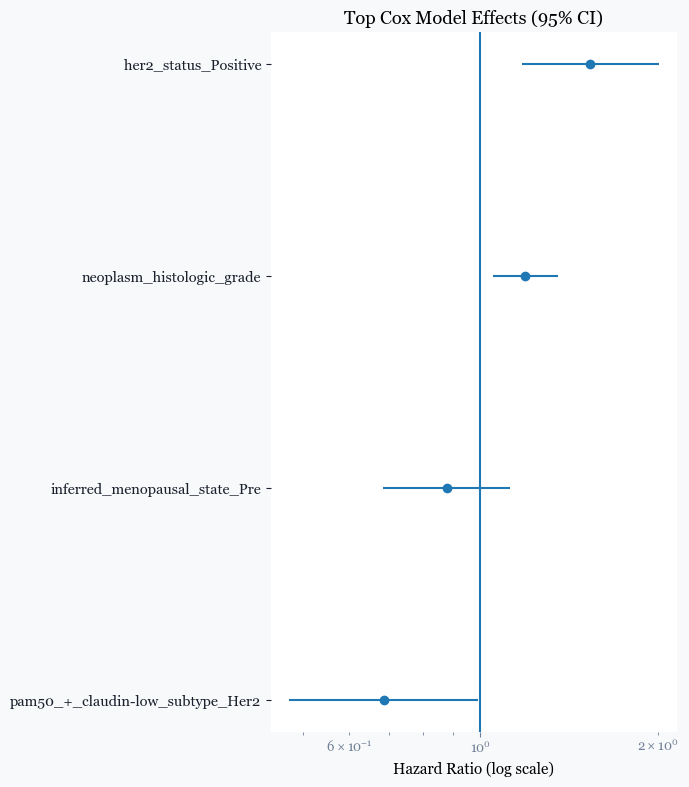

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract summary table
summary = cph.summary.copy()

# Select strongest effects (by absolute z-score)
top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(4)
    .sort_values("coef")
)

plt.figure(figsize=(7, 8))
plt.errorbar(
    top["exp(coef)"],
    top.index,
    xerr=[
        top["exp(coef)"] - top["exp(coef) lower 95%"],
        top["exp(coef) upper 95%"] - top["exp(coef)"],
    ],
    fmt="o"
)

plt.axvline(1.0)
plt.xlabel("Hazard Ratio (log scale)")
plt.xscale("log")
plt.title("Top Cox Model Effects (95% CI)")
plt.tight_layout()
plt.show()


In [283]:
df_cox["inferred_menopausal_state_Pre"]

0       0
1       1
2       1
3       1
4       0
       ..
1899    1
1900    1
1901    0
1902    0
1903    0
Name: inferred_menopausal_state_Pre, Length: 1814, dtype: int64

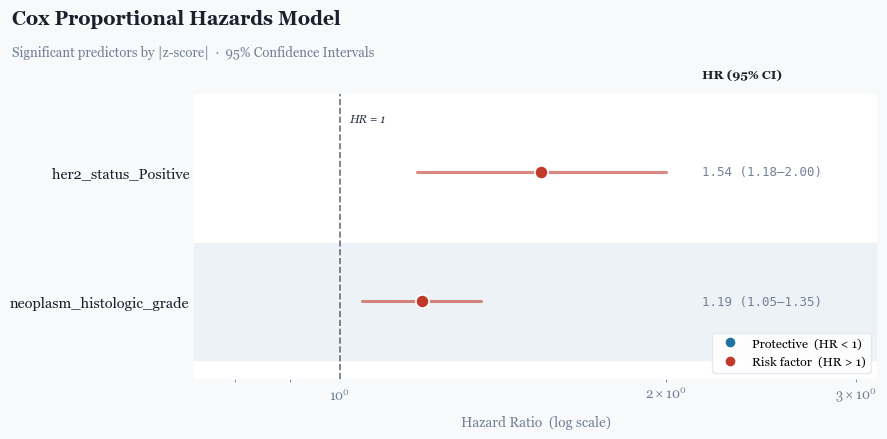

Saved → cox_forest_plot_styled.png


In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Style config ───────────────────────────────────────────────────────────────
BACKGROUND   = "#F7F9FB"
PANEL_BG     = "#FFFFFF"
GRID_COLOR   = "#E2E8F0"
TEXT_DARK    = "#1A202C"
TEXT_MUTED   = "#718096"
ACCENT_POS   = "#C0392B"   # red  → HR > 1  (increased risk)
ACCENT_NEG   = "#2471A3"   # blue → HR < 1  (protective)
REFLINE      = "#2D3748"

plt.rcParams.update({
    "font.family":       "Georgia",
    "font.size":         11,
    "axes.facecolor":    PANEL_BG,
    "figure.facecolor":  BACKGROUND,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom":False,
    "xtick.color":       TEXT_MUTED,
    "ytick.color":       TEXT_DARK,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   10.5,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
summary = cph.summary.copy()

top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(2)
    .sort_values("coef")          # ascending coef = protective vars on top
)

hr      = top["exp(coef)"].values
hr_lo   = top["exp(coef) lower 95%"].values
hr_hi   = top["exp(coef) upper 95%"].values
names   = top.index.tolist()
n       = len(names)
y_pos   = np.arange(n)

# colour each row by direction of effect
point_colors = [ACCENT_NEG if h < 1 else ACCENT_POS for h in hr]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(PANEL_BG)

# subtle horizontal grid bands (alternating)
for i in y_pos:
    ax.axhspan(i - 0.45, i + 0.45,
               color="#EDF2F7" if i % 2 == 0 else PANEL_BG,
               zorder=0)

# vertical reference line at HR = 1
ax.axvline(1.0, color=REFLINE, linewidth=1.2,
           linestyle="--", zorder=2, alpha=0.7)
ax.text(1.02, n - 0.55, "HR = 1", color=REFLINE,
        fontsize=8.5, style="italic", va="top")

# CI whiskers
for i, (lo, hi, y, col) in enumerate(zip(hr_lo, hr_hi, y_pos, point_colors)):
    ax.plot([lo, hi], [y, y], color=col, linewidth=2.2,
            solid_capstyle="round", zorder=3, alpha=0.6)

# Point estimates
for y, h, col in zip(y_pos, hr, point_colors):
    ax.scatter(h, y, color=col, s=90, zorder=4,
               edgecolors="white", linewidths=1.2)

# HR labels to the right of CI
x_label_pos = hr_hi.max() * 1.08
for y, h, lo, hi in zip(y_pos, hr, hr_lo, hr_hi):
    label = f"{h:.2f} ({lo:.2f}–{hi:.2f})"
    ax.text(x_label_pos, y, label,
            va="center", ha="left",
            fontsize=9, color=TEXT_MUTED,
            fontfamily="monospace")

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=10.5, color=TEXT_DARK)
ax.set_xlabel("Hazard Ratio  (log scale)", fontsize=10,
              color=TEXT_MUTED, labelpad=8)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="x", length=3, color=GRID_COLOR)
ax.tick_params(axis="y", length=0)

# extend x-axis to make room for labels
ax.set_xlim(hr_lo.min() * 0.7, x_label_pos * 1.45)

# column header for HR label block
ax.text(x_label_pos, n - 0.3, "HR (95% CI)",
        va="bottom", ha="left",
        fontsize=9, color=TEXT_DARK, fontweight="bold")

# ── Title block ───────────────────────────────────────────────────────────────
fig.text(0.02, 0.97, "Cox Proportional Hazards Model",
         fontsize=14, fontweight="bold", color=TEXT_DARK, va="top")
fig.text(0.02, 0.89, "Significant predictors by |z-score|  ·  95% Confidence Intervals",
         fontsize=9.5, color=TEXT_MUTED, va="top")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_NEG,
           markersize=8, label="Protective  (HR < 1)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_POS,
           markersize=8, label="Risk factor  (HR > 1)"),
]
ax.legend(handles=legend_elements, loc="lower right",
          frameon=True, framealpha=0.9,
          edgecolor=GRID_COLOR, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("cox_forest_plot_styled.png", dpi=180, bbox_inches="tight",
            facecolor=BACKGROUND)
plt.show()
print("Saved → cox_forest_plot_styled.png")

In [285]:
# See the actual distribution
df_cox["neoplasm_histologic_grade"].value_counts().sort_index()

# Cross-tab against survival to sense-check direction
df_cox.groupby("neoplasm_histologic_grade")["event"].mean()

neoplasm_histologic_grade
1.0    0.394995
2.0    0.438525
3.0    0.552147
Name: event, dtype: float64

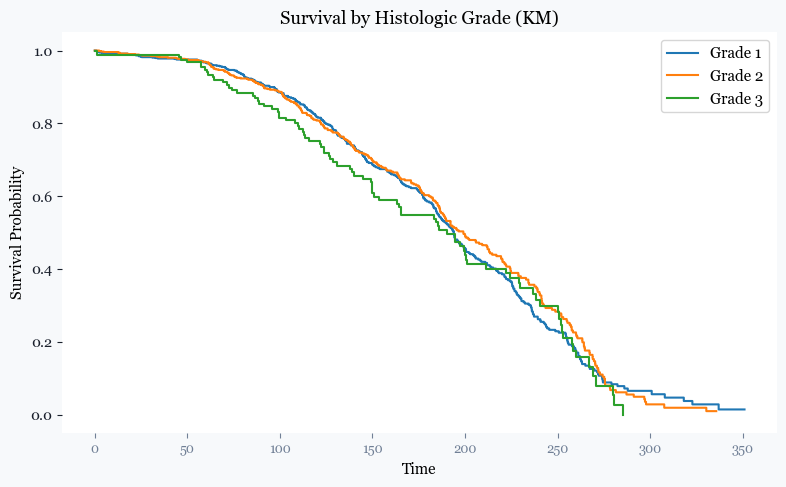

In [286]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for grade in sorted(df_cox["neoplasm_histologic_grade"].unique()):
    mask = df_cox["neoplasm_histologic_grade"] == grade
    kmf = KaplanMeierFitter()
    kmf.fit(
        df_cox.loc[mask, "time"],
        df_cox.loc[mask, "event"],
        label=f"Grade {int(grade)}"
    )
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_title("Survival by Histologic Grade (KM)")
ax.set_xlabel("Time")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

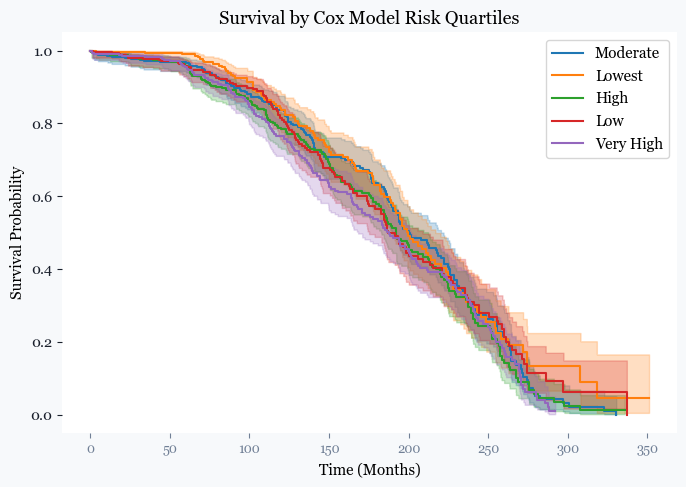

In [287]:
from lifelines import KaplanMeierFitter
from matplotlib import pyplot as plt

# Compute risk scores
df_cox["risk_score"] = cph.predict_partial_hazard(df_cox)

# Define risk groups
df_cox["risk_group"] = pd.qcut(
    df_cox["risk_score"],
    #q=4, labels=["Low", "Mid-Low", "Mid-High", "High"],
    q=5, labels=["Lowest", "Low", "Moderate", "High", "Very High"]
)

kmf = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

for group in df_cox["risk_group"].unique():
    ix = df_cox["risk_group"] == group
    kmf.fit(
        df_cox.loc[ix, "time"],
        event_observed=df_cox.loc[ix, "event"],
        label=group
    )
    kmf.plot_survival_function()

plt.title("Survival by Cox Model Risk Quartiles")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()


In [288]:
def plot_calibration(cph, df_cox, landmark_time=5.0,
                     duration_col="time", event_col="event",
                     n_bins=10):
    """
    At `landmark_time`, compare model-predicted survival probability
    against the observed KM-estimated survival for decile bins.
    """
    # Predicted survival probability at the landmark for every patient
    pred_surv = cph.predict_survival_function(df_cox, times=[landmark_time])
    predicted = pred_surv.iloc[0].values  # shape (n_patients,)
 
    # Bin patients by predicted probability
    df_cal = pd.DataFrame({
        duration_col: df_cox[duration_col].values,
        event_col:    df_cox[event_col].values,
        "predicted":  predicted,
    })
    df_cal["bin"] = pd.qcut(df_cal["predicted"], q=n_bins, duplicates="drop")
 
    # Observed KM probability at landmark per bin
    obs_list, pred_list = [], []
    for _, grp in df_cal.groupby("bin", observed=True):
        kmf = KaplanMeierFitter()
        kmf.fit(grp[duration_col], grp[event_col])
        # Interpolate KM estimate at landmark_time
        km_at_t = kmf.survival_function_at_times([landmark_time]).values[0]
        obs_list.append(km_at_t)
        pred_list.append(grp["predicted"].mean())
 
    obs_arr  = np.array(obs_list)
    pred_arr = np.array(pred_list)
 
    # LOWESS smoother
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(obs_arr, pred_arr, frac=0.75)
 
    fig, ax = plt.subplots(figsize=(6, 6))
 
    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
 
    # Bin-level points
    ax.scatter(pred_arr, obs_arr, color="#2166ac", s=60, zorder=3,
               label="Decile bins")
 
    # LOWESS curve
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="#d6604d",
            linewidth=2, label="LOWESS smoother")
 
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(f"Predicted {landmark_time}-year Survival Probability")
    ax.set_ylabel(f"Observed {landmark_time}-year Survival (KM)")
    ax.set_title(f"Calibration Plot at {landmark_time} Years")
    ax.legend(frameon=False)
 
    plt.tight_layout()
    #plt.savefig("calibration_plot.png", bbox_inches="tight")
    plt.show()

In [289]:
def plot_roc_landmark(cph, df_cox, landmark_time=5.0,
                      duration_col="time", event_col="event"):
    """
    Landmark ROC: restrict to patients still at risk at `landmark_time`,
    then use 1 - predicted_survival as the score for a binary outcome
    (did the event occur before landmark_time?).
 
    Also plots AUC as a function of time using a simple sweep.
    """
    # ── Panel A: ROC at landmark ──────────────────────────────────────────────
    # Restrict to patients at risk at landmark (not yet had event)
    at_risk_mask = df_cox[duration_col] >= landmark_time
    df_lr = df_cox[at_risk_mask].copy()
 
    # Binary outcome: did event occur within landmark window from enrollment?
    # Here we use all patients and define outcome as event before landmark
    pred_all = cph.predict_survival_function(df_cox, times=[landmark_time])
    scores   = 1 - pred_all.iloc[0].values   # higher = higher risk
 
    # Binary label: event occurred AND time <= landmark
    labels = ((df_cox[event_col] == 1) &
              (df_cox[duration_col] <= landmark_time)).astype(int).values
 
    fpr, tpr, _ = roc_curve(labels, scores)
    auc_val = roc_auc_score(labels, scores)
 
    # ── Panel B: AUC over time ────────────────────────────────────────────────
    time_points = np.percentile(
        df_cox.loc[df_cox[event_col] == 1, duration_col],
        np.linspace(10, 90, 20)
    )
    auc_over_time = []
    for t in time_points:
        pred_t = cph.predict_survival_function(df_cox, times=[t])
        s_t    = 1 - pred_t.iloc[0].values
        lbl_t  = ((df_cox[event_col] == 1) &
                  (df_cox[duration_col] <= t)).astype(int).values
        if lbl_t.sum() < 5 or lbl_t.sum() == len(lbl_t):
            auc_over_time.append(np.nan)
        else:
            auc_over_time.append(roc_auc_score(lbl_t, s_t))
 
    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
    # Left: ROC curve at landmark
    ax = axes[0]
    ax.plot(fpr, tpr, color="#2166ac", linewidth=2.5,
            label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate (1 – Specificity)")
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_title(f"ROC Curve at {landmark_time}-Year Landmark")
    ax.legend(loc="lower right", frameon=False)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
 
    # Right: AUC(t)
    ax2 = axes[1]
    ax2.plot(time_points, auc_over_time, color="#d6604d",
             linewidth=2.5, marker="o", markersize=4)
    ax2.axhline(0.5, color="black", linestyle="--", linewidth=1,
                label="Random (AUC = 0.5)")
    ax2.axvline(landmark_time, color="#4dac26", linestyle=":",
                linewidth=1.5, label=f"Landmark = {landmark_time}yr")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("AUC")
    ax2.set_title("Time-Dependent AUC")
    ax2.set_ylim(0.4, 1.0)
    ax2.legend(frameon=False)
 
    plt.tight_layout()
    #plt.savefig("roc_auc_plot.png", bbox_inches="tight")
    plt.show()
    #print("Saved → roc_auc_plot.png")

In [290]:
plot_roc_landmark(cph, df_cox, landmark_time=5.0,
                      duration_col="time", event_col="event")

NameError: name 'roc_curve' is not defined

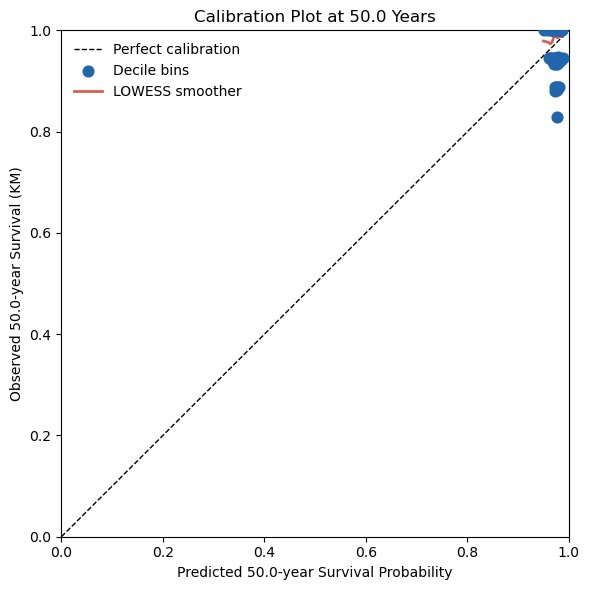

In [ ]:
plot_calibration(cph, df_cox, landmark_time=50.0,
                     duration_col="time", event_col="event",
                     n_bins=100)